Group Project: Naomi Sanborn 
55 Cnc Authors: Howard Andrew W and Fulton Benjamin J
Ask if guessing points on k t t0 and p and gamma for information to fit to curve sin() for Rv_model during TA hours

Fit Results: K=-2.11 m/s, P=0.7365 days


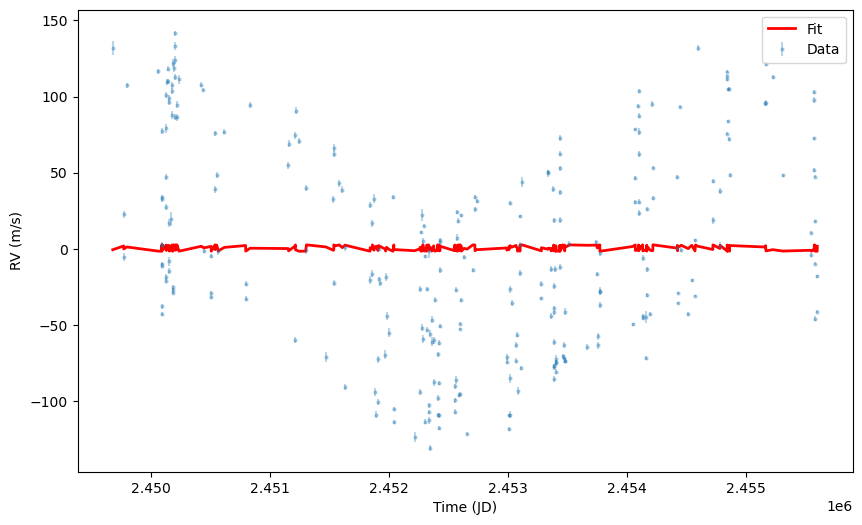

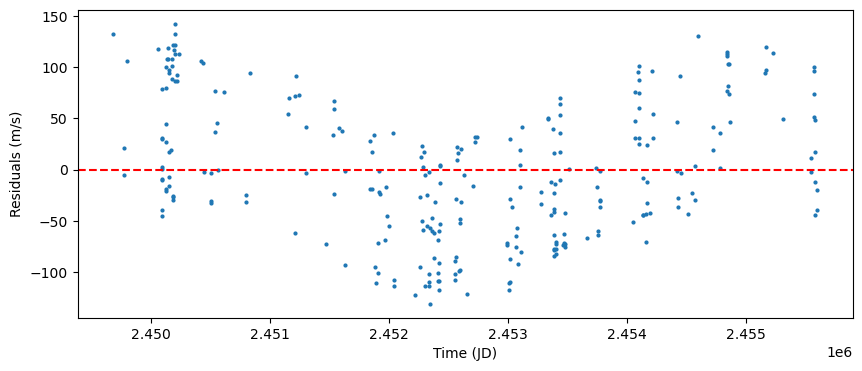

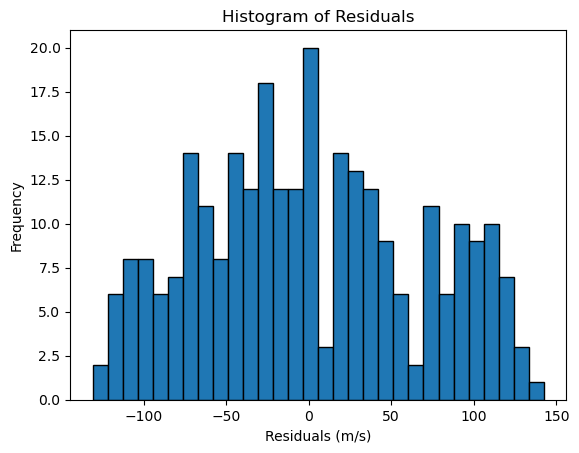

Standard deviation of residuals: 67.03 m/s
Estimated planet mass: -0.063 Jupiter masses


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Load data (assuming file '55Cnc_rv.txt' with columns: Time, RV, Error)
data = np.loadtxt('Radial.txt', skiprows=22)
time = data[:,0]
rv = data[:,1]
rv_err = data[:,2]

# Oscillatory function
K_guess = 10
P_guess = 0.7365
t0_guess = 2450000
gamma_guess = np.mean(rv)
def rv_model(t, K, P, t0, gamma):
    return K * np.sin(2 * np.pi * (t - t0) / P) + gamma

# Fit
params,params_cov = curve_fit(rv_model, time, rv, p0=[K_guess, P_guess, t0_guess, gamma_guess])
K_fit, P_fit, t0_fit, gamma_fit = params
print(f"Fit Results: K={K_fit:.2f} m/s, P={P_fit:.4f} days")

# Plot Data + Model
time_sorted = np.sort(time)
plt.figure(figsize=(10, 6))
plt.errorbar(time, rv, yerr=rv_err, fmt='o', markersize=2, alpha=0.3, label='Data')
plt.plot(time_sorted, rv_model(time_sorted, *popt), color='red', label='Fit', linewidth=2)
plt.xlabel('Time (JD)')
plt.ylabel('RV (m/s)')
plt.legend()
plt.show()

residuals = rv - rv_model(time, *popt)
plt.figure(figsize=(10, 4))
plt.plot(time, residuals, 'o', markersize=2)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Time (JD)')
plt.ylabel('Residuals (m/s)')
plt.show()

# Histogram of residuals
plt.hist(residuals, bins=30, edgecolor='black')
plt.xlabel('Residuals (m/s)')
plt.ylabel('Frequency')
plt.title('Histogram of Residuals')
plt.show()
print(f"Standard deviation of residuals: {np.std(residuals):.2f} m/s") 
# mass of the host star (solar masses)
M_star = 0.905
Mp = (K_fit * (P_fit**(1/3)) * (M_star**(2/3))) / 28.4329
print(f"Estimated planet mass: {Mp:.3f} Jupiter masses")